# 11 - 手写 BasicPPO (RLHF-PPO 最小实现)

> 配套笔记: 05-RL/01 RL训练基础 - loop 与 RLHF-PPO (draft, 发布后补链接)

单文件 toy 规模 (词表 100 / hidden 64, CPU 秒级, T4 直接跑): 四个模型 (actor / critic / RM / ref) + 完整 PPO loop + 正确性验证。

- **§1-3**: 四个纯函数 + 组件 + loop 骨架, 对齐笔记 §4.3
- **§4 验证**: 跑通 ≠ 算法对——单测四函数 + reward-go-up, 对应笔记 §6
- **§5**: 与真实实现的 delta

## 0. 环境

仅需 torch (+ matplotlib 画曲线)。CPU 秒级跑通; `device=` 已加, 有 GPU 也能跑。

> 本系列其它 notebook 多用 T4; 这篇有意 toy + CPU。RL 正确性只能靠 reward-go-up (§4)、没有 real-world 参照可对; 放大到真实四模型 T4 也装不下 (笔记 §5)。小规模看得清、秒出结果。

In [1]:
import copy, torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0)
print('device:', DEVICE, '| torch', torch.__version__)

device: cpu | torch 2.11.0+cpu


## 🌟 1. 高频手撕: 四个纯函数 ｜ 笔记 §4.3 核心

全 mask-aware (变长 response 的 pad 屏蔽), `compute_gae` / `ppo_loss` 最高频:

- `sft_logprob`: shift + gather 取逐 token logprob (§3.0)
- `compute_rewards`: `r_t` = 每位 KL 惩罚 + 末位 RM 分 (§3.2)
- `compute_gae`: 倒序递推 `A_t = δ_t + γλ A_{t+1}` (§3.4)
- `ppo_loss`: ratio + clip (§3.5 / §3.6)

In [2]:
def sft_logprob(model, ids, p_len):
    """SFT 式逐 token logprob, response 段 (B, T_resp)"""
    logp = model(ids[:, :-1]).log_softmax(-1)      # (B, T-1, V) 位置 j 预测 ids[j+1]
    tgt  = ids[:, 1:].unsqueeze(-1)                # (B, T-1, 1) shift 一位当 label
    logp = logp.gather(-1, tgt).squeeze(-1)        # (B, T-1)    取实际 token 那一格
    return logp[:, p_len - 1:]                     # (B, T_resp) 只留 response 段

def compute_rewards(old_logp, ref_logp, r_rm, mask, beta=0.1):
    """r_t = 每位 KL 惩罚 + 最后有效位叠 RM 分 (§3.2)"""
    r = -beta * (old_logp - ref_logp) * mask       # KL 惩罚, pad 位清零
    last = mask.sum(1).long() - 1                   # 每条最后一个有效 token 下标
    r[torch.arange(len(r), device=r.device), last] += r_rm   # RM 分加在最后有效位
    return r

def compute_gae(r, v, mask, gamma=1.0, lam=0.95):
    """倒序递推 GAE (§3.4); 返回 (A_t, G_t=A_t+V) 后者给 critic 当回归 label"""
    adv, A = torch.zeros_like(r), 0
    for t in reversed(range(r.shape[1])):
        if t + 1 < r.shape[1]:
            nonterm = mask[:, t + 1]               # 下一位是否仍是有效 token
            v_next  = v[:, t + 1] * nonterm
        else:
            nonterm, v_next = 0, 0                 # 序列最右端, 无下一状态
        delta = r[:, t] + gamma * v_next - v[:, t]         # 单步 TD 残差 δ_t
        A = delta + gamma * lam * nonterm * A               # 跨到 pad 时 nonterm=0, 重置
        adv[:, t] = A
    return adv * mask, (adv + v) * mask            # pad 位清零

def ppo_loss(new_logp, old_logp, adv, mask, eps=0.2):
    """clip 版 actor loss (§3.6): -E[min(rho*A, clip(rho,1±eps)*A)], 只在有效位取均值"""
    ratio = (new_logp - old_logp).exp()            # ρ_t = π_θ / π_old
    surr1 = ratio * adv                            # 不截断
    surr2 = ratio.clamp(1 - eps, 1 + eps) * adv    # 截断到 [1-ε, 1+ε]
    loss  = -torch.min(surr1, surr2)               # 出界那侧梯度 = 0
    return (loss * mask).sum() / mask.sum()        # masked mean

## 2. 组件: 四个模型 ｜ 辅助

两种结构: 带 lm_head 的 Actor, 带标量 head 的 ScalarLM (critic 与 RM 同构); ref 是 actor 冻结副本。`dropout=0.0` 保证前向确定, 否则 `old_logp` 与 rollout 用的策略对不上 (§4.2 会暴露)。

In [3]:
V, D = 100, 64                                   # 词表 / hidden, toy 规模
EOS = 0                                           # 约定 token 0 为 EOS

class MiniLM(nn.Module):
    """共用 backbone: embedding + 2 层 causal transformer, 输出每位置 hidden"""
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(V, D)
        layer = nn.TransformerEncoderLayer(D, nhead=4, dim_feedforward=4 * D,
                                           dropout=0.0, batch_first=True)  # 关 dropout: 确定
        self.blocks = nn.TransformerEncoder(layer, num_layers=2)
    def forward(self, ids):                      # [B,T] -> [B,T,D]
        mask = nn.Transformer.generate_square_subsequent_mask(ids.shape[1], device=ids.device)
        return self.blocks(self.emb(ids), mask=mask, is_causal=True)

class Actor(nn.Module):
    """LLM 本体: backbone + lm_head"""
    def __init__(self):
        super().__init__()
        self.lm, self.lm_head = MiniLM(), nn.Linear(D, V)
    def forward(self, ids):                      # -> [B,T,V] logits
        return self.lm_head(self.lm(ids))
    @torch.no_grad()
    def generate(self, ids, n_new):              # toy 版 rollout, 无 KV cache
        for _ in range(n_new):                   # 真实系统这段走推理引擎 (§5)
            p = self(ids)[:, -1].softmax(-1)
            ids = torch.cat([ids, torch.multinomial(p, 1)], dim=1)
        return ids                               # 定长 n_new, EOS 之后靠 mask 屏蔽

class ScalarLM(nn.Module):
    """critic 与 RM 同构: backbone + 标量 head"""
    def __init__(self):
        super().__init__()
        self.lm, self.head = MiniLM(), nn.Linear(D, 1)
    def forward(self, ids):                      # -> [B,T] 每位置一个标量
        return self.head(self.lm(ids)).squeeze(-1)

actor  = Actor().to(DEVICE)                       # ✅ 训练
critic = ScalarLM().to(DEVICE)                    # ✅ 训练 (实际常从 RM 初始化)
rm     = ScalarLM().to(DEVICE).eval()             # ❄️ 冻结; 随机权重代替训好的 RM
ref    = copy.deepcopy(actor).eval()              # ❄️ 冻结; actor 出发点副本

## 🌟 3. 一个 training step ｜ 笔记 §4.3 loop

时序: ① rollout → ② no-grad 前向 ×4 (experiences) → ③ 组装 `r_t` + GAE → ④ update × ppo-epochs。只有 ④ 带梯度。

In [4]:
opt = torch.optim.Adam([*actor.parameters(), *critic.parameters()], lr=1e-4)

def ppo_step(prompt, n_new=16, ppo_epochs=4):
    p_len, B = prompt.shape[1], prompt.shape[0]
    # ① rollout: 推理负载
    ids = actor.generate(prompt, n_new)
    # response 变长: 各条在不同位置生成 EOS, EOS 之后是 pad, 要 mask 掉
    eos  = (ids[:, p_len:] == EOS).long()            # (B, n_new) EOS 处为 1
    mask = (eos.cumsum(1) - eos == 0).float()        # 到首个 EOS(含) 为 1, 之后 pad 为 0
    last = mask.sum(1).long() - 1                     # (B,) 每条最后一个有效 token 下标
    # ② no-grad 前向 x4, 产物即 experiences, 更新期间全程当常数
    with torch.no_grad():
        old_logp = sft_logprob(actor, ids, p_len)  # rho_t 的分母 (§3.5)
        ref_logp = sft_logprob(ref, ids, p_len)    # KL 基准 (§3.2)
        v        = critic(ids)[:, p_len - 1:-1]     # 每个 response 位置的 V(s_t)
        r_rm     = rm(ids)[torch.arange(B, device=ids.device), p_len + last]  # 末位标量 = 整条分 (§4.1)
    # ③ reward 组装 + GAE
    rewards  = compute_rewards(old_logp, ref_logp, r_rm, mask)
    adv, ret = compute_gae(rewards, v, mask)
    # ④ update: 同一批 experiences 复用 ppo-epochs 次, 训练负载
    for _ in range(ppo_epochs):
        new_logp = sft_logprob(actor, ids, p_len)  # 唯一带梯度的 logprob
        actor_loss = ppo_loss(new_logp, old_logp, adv, mask)
        v_pred     = critic(ids)[:, p_len - 1:-1]
        value_loss = ((v_pred - ret) ** 2 * mask).sum() / mask.sum()   # masked MSE
        opt.zero_grad(); (actor_loss + 0.5 * value_loss).backward(); opt.step()
    return actor_loss.item(), value_loss.item()

## 4. 正确性验证 ｜ 笔记 §6 核心

RL 没有逐 token GT, **跑通 ≠ 算法对** (符号反、clip 反向、mask 漏都能跑通)。两步查: 逐函数对参照 (4.2) + 整体看 reward 涨 (4.3); 外加一道接线检查 (4.1)。

### 4.1 跑通 + 梯度流向

不崩、shape 对; 关键是**梯度只到 actor / critic**: rm / ref 的 `.grad` 为 `None`、参数不变。

In [5]:
ref_snap = [p.clone() for p in ref.parameters()]
a, vl = ppo_step(torch.randint(1, V, (2, 8), device=DEVICE))
print(f"跑通: actor_loss={a:+.4f} value_loss={vl:.4f}")

assert all(torch.equal(p, q) for p, q in zip(ref.parameters(), ref_snap)), "ref 被改动!"
assert all(p.grad is None for p in rm.parameters()),  "rm 有梯度!"
assert all(p.grad is None for p in ref.parameters()), "ref 有梯度!"
assert any(p.grad is not None for p in actor.parameters()),  "actor 无梯度!"
assert any(p.grad is not None for p in critic.parameters()), "critic 无梯度!"
print("梯度流向: rm/ref 无梯度且不变, actor/critic 有梯度  OK")

跑通: actor_loss=-0.2844 value_loss=0.2855
梯度流向: rm/ref 无梯度且不变, actor/critic 有梯度  OK


### 4.2 单测四个纯函数

每个函数一个能算准的参照 (前提: §2 已关 dropout):

| 函数 | 参照 |
|---|---|
| `sft_logprob` | 真 token logprob = −CE, 与 `-F.cross_entropy` 对齐 |
| `compute_rewards` | `actor==ref` → KL 恒 0, 只剩末位 RM 分, 落在最后有效 token |
| `compute_gae` | `λ=1`→G−V、`λ=0`→δ; 中间与暴力展开 `Σ(γλ)^l δ` 对齐; pad 清零 |
| `ppo_loss` | ratio 出界朝"继续推"→梯度 0、"往回修"→保留; `ratio=1` 退化成 policy gradient |

In [6]:
# A. sft_logprob == -CE(真 token)
m = Actor().to(DEVICE)
ids, p_len = torch.randint(1, V, (2, 10), device=DEVICE), 4
logits = m(ids[:, :-1])
ce = F.cross_entropy(logits.reshape(-1, V), ids[:, 1:].reshape(-1), reduction='none').reshape(2, -1)
assert torch.allclose(sft_logprob(m, ids, p_len), (-ce)[:, p_len - 1:], atol=1e-5)
print("A  sft_logprob == -CE  OK")

# B. compute_rewards: KL=0 时只剩末位 RM 分, 落在最后有效 token
lp   = torch.randn(2, 6, device=DEVICE)
mask = torch.tensor([[1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 1, 1]], device=DEVICE).float()
r_rm = torch.tensor([2.0, -1.0], device=DEVICE)
r = compute_rewards(lp, lp, r_rm, mask)                     # actor==ref
assert r[0, 3] == 2.0 and r[0, 5] == 0.0                    # 最后有效位 3, 不是字面末位 5
assert torch.allclose(r[1, :5], torch.zeros(5, device=DEVICE)) and r[1, 5] == -1.0
print("B  compute_rewards: KL=0 只剩末位 RM 分, 落在最后有效 token  OK")

# C. compute_gae: 边界恒等式 + 暴力对齐 + pad 清零
r, vv, full = torch.randn(2, 6, device=DEVICE), torch.randn(2, 6, device=DEVICE), torch.ones(2, 6, device=DEVICE)
G = torch.flip(torch.cumsum(torch.flip(r, [1]), 1), [1])    # G_t = suffix sum (gamma=1)
assert torch.allclose(compute_gae(r, vv, full, lam=1.0)[0], G - vv, atol=1e-5)          # lam=1 -> G-V
v_next = torch.cat([vv[:, 1:], torch.zeros(2, 1, device=DEVICE)], 1)
delta  = r + v_next - vv
assert torch.allclose(compute_gae(r, vv, full, lam=0.0)[0], delta, atol=1e-5)           # lam=0 -> delta
brute = sum((0.95 ** l) * F.pad(delta, (0, l))[:, l:] for l in range(6))                # Sigma (gl)^l delta
assert torch.allclose(compute_gae(r, vv, full, lam=0.95)[0], brute, atol=1e-5)          # 中间值
adv_p, ret_p = compute_gae(torch.randn(1, 6, device=DEVICE), torch.randn(1, 6, device=DEVICE),
                           torch.tensor([[1, 1, 1, 0, 0, 0]], device=DEVICE).float())
assert (adv_p[:, 3:] == 0).all() and (ret_p[:, 3:] == 0).all()                          # pad 清零
print("C  compute_gae: lam=1->G-V, lam=0->delta, 中间对齐暴力展开, pad 清零  OK")

# D. ppo_loss: clip 方向 + ratio=1 退化
old, one = torch.zeros(1, 1, device=DEVICE), torch.ones(1, 1, device=DEVICE)
n1 = torch.ones(1, 1, device=DEVICE, requires_grad=True)    # ratio=e~2.72 出上界
ppo_loss(n1, old, torch.tensor([[1.0]], device=DEVICE), one).backward()
assert torch.allclose(n1.grad, torch.zeros_like(n1.grad))                               # A>0 顺优势 -> 梯度 0
n2 = torch.ones(1, 1, device=DEVICE, requires_grad=True)
ppo_loss(n2, old, torch.tensor([[-1.0]], device=DEVICE), one).backward()
assert not torch.allclose(n2.grad, torch.zeros_like(n2.grad))                           # A<0 逆优势 -> 保留
adv3 = torch.randn(1, 1, device=DEVICE)
assert torch.allclose(ppo_loss(old.clone().requires_grad_(True), old, adv3, one), -adv3.mean())  # ratio=1
print("D  ppo_loss: 顺优势出界梯度=0, 逆优势保留, ratio=1 退化成 policy gradient  OK")

A  sft_logprob == -CE  OK
B  compute_rewards: KL=0 只剩末位 RM 分, 落在最后有效 token  OK
C  compute_gae: lam=1->G-V, lam=0->delta, 中间对齐暴力展开, pad 清零  OK
D  ppo_loss: 顺优势出界梯度=0, 逆优势保留, ratio=1 退化成 policy gradient  OK


### 4.3 reward-go-up (端到端金标准)

拼起来没有闭式参照。把随机 RM 换成确定 toy reward ("目标 token 越多分越高"), 训几百 step, batch 平均 reward 单调上升即符号约定整体自洽 (不涨 → advantage 没乘 / clip 反 / KL 太强)。`β=0` 隔离 reward 信号, advantage 白化稳尺度。

first-20 avg = 0.28  ->  last-20 avg = 11.90
reward-go-up: batch 平均 reward 明显上升  OK


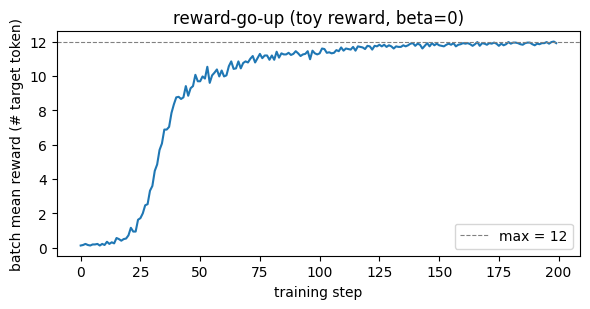

In [7]:
import matplotlib.pyplot as plt

TARGET = 7                                        # 目标 token, 出现越多分越高
def toy_reward(ids, p_len, mask):
    resp = ids[:, p_len:]
    return ((resp == TARGET).float() * mask).sum(1)   # (B,) 有效位里 target 计数

torch.manual_seed(0)                              # 重新初始化, 从头训
actor  = Actor().to(DEVICE)
critic = ScalarLM().to(DEVICE)
ref    = copy.deepcopy(actor).eval()
opt    = torch.optim.Adam([*actor.parameters(), *critic.parameters()], lr=1e-4)

curve = []
for step in range(200):
    prompt = torch.randint(1, V, (32, 4), device=DEVICE)
    p_len, B = prompt.shape[1], prompt.shape[0]
    ids = actor.generate(prompt, 12)
    eos  = (ids[:, p_len:] == EOS).long()
    mask = (eos.cumsum(1) - eos == 0).float()
    with torch.no_grad():
        old_logp = sft_logprob(actor, ids, p_len)
        ref_logp = sft_logprob(ref, ids, p_len)
        v        = critic(ids)[:, p_len - 1:-1]
        r_rm     = toy_reward(ids, p_len, mask)
    rewards  = compute_rewards(old_logp, ref_logp, r_rm, mask, beta=0.0)   # beta=0 隔离 reward
    adv, ret = compute_gae(rewards, v, mask)
    valid = mask.bool()
    adv = ((adv - adv[valid].mean()) / (adv[valid].std() + 1e-8)) * mask   # advantage 白化
    for _ in range(4):
        new_logp = sft_logprob(actor, ids, p_len)
        a_loss = ppo_loss(new_logp, old_logp, adv, mask)
        v_pred = critic(ids)[:, p_len - 1:-1]
        v_loss = ((v_pred - ret) ** 2 * mask).sum() / mask.sum()
        opt.zero_grad(); (a_loss + 0.5 * v_loss).backward(); opt.step()
    curve.append(r_rm.mean().item())

first20, last20 = sum(curve[:20]) / 20, sum(curve[-20:]) / 20
print(f"first-20 avg = {first20:.2f}  ->  last-20 avg = {last20:.2f}")
assert last20 > first20 + 2.0 and curve[-1] > 8.0, "reward 没有明显上升!"
print("reward-go-up: batch 平均 reward 明显上升  OK")

plt.figure(figsize=(6, 3.2))
plt.plot(curve, lw=1.5)
plt.axhline(12, ls='--', c='gray', lw=0.8, label='max = 12')
plt.xlabel('training step'); plt.ylabel('batch mean reward (# target token)')
plt.title('reward-go-up (toy reward, beta=0)'); plt.legend(); plt.tight_layout(); plt.show()

## 5. 与真实实现的 delta ｜ 辅助

- **变长 prompt**: 左 pad + attention mask (toy prompt 等长, 只处理了变长 response)
- **KL 的另一种放法**: 不进 `r_t`, 直接加进 loss (`L + β·KL`); GRPO 用法, 02 篇展开
- **双引擎**: `generate` 走推理引擎 (vLLM), update 走训练引擎 (Megatron / FSDP), 同权重两套系统各存一份; §5 起全系列在处理这件事
- **训练稳定性 trick**: advantage 白化 (§4.3 已用)、reward clip、entropy bonus、value clip、actor / critic 分开 optimizer